In [1]:
cd ..

c:\Users\rahar\Desktop\master\BIOCOMP\backup\practica_biocomp


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from genetic.algorithms import GeneticAlgorithmMO
from genetic.configurations import ProblemConfig
from genetic.crossover import BlendCrossover
from genetic.initialization import RandomInitialization
from genetic.mutation import UniformMutation
from genetic.problems import PymooProblem
from genetic.replacement import GenerationalReplacement
from genetic.selection import ParetoSelection

# First try

In [4]:
config = ProblemConfig(max_evaluations=10000, seed=42, output_dir="results/zdt1")

# Problem
name = "zdt3"
problem = PymooProblem(config, name, n_var=30)

# Operators
initialization = RandomInitialization()
selection = ParetoSelection()
crossover = BlendCrossover(alpha=0.5)
mutation = UniformMutation(mutation_rate=0.15, bounds=problem.get_bounds())
replacement = GenerationalReplacement()

# Genetic Algorithm
ga = GeneticAlgorithmMO(
    problem=problem,
    population_size=50,
    initialization=initialization,
    selection=selection,
    crossover=crossover,
    mutation=mutation,
    replacement=replacement,
)

In [5]:
print("=" * 80)
print("OPTIMIZING ZDT3 FUNCTIONS")
print("=" * 80)
result = ga.run()

OPTIMIZING ZDT3 FUNCTIONS
Gen 0: Evals=50/10000, Pareto size=6, Sample objectives=['0.6394', '2.3997']
Gen 10: Evals=550/10000, Pareto size=13, Sample objectives=['0.1166', '4.2555']
Gen 20: Evals=1050/10000, Pareto size=16, Sample objectives=['0.3270', '3.1912']
Gen 30: Evals=1550/10000, Pareto size=19, Sample objectives=['0.6398', '2.2169']
Gen 40: Evals=2050/10000, Pareto size=20, Sample objectives=['0.0000', '3.9031']
Gen 50: Evals=2550/10000, Pareto size=19, Sample objectives=['0.6071', '2.0760']
Gen 60: Evals=3050/10000, Pareto size=19, Sample objectives=['0.3004', '3.2757']
Gen 70: Evals=3550/10000, Pareto size=18, Sample objectives=['0.0287', '4.0900']
Gen 80: Evals=4050/10000, Pareto size=21, Sample objectives=['0.2749', '3.1577']
Gen 90: Evals=4550/10000, Pareto size=18, Sample objectives=['0.8680', '2.2681']
Gen 100: Evals=5050/10000, Pareto size=19, Sample objectives=['0.0231', '4.2558']
Gen 110: Evals=5550/10000, Pareto size=19, Sample objectives=['0.6068', '3.3435']
Gen 1

In [6]:
print("\n" + "=" * 40)
print("RESULTS")
print("=" * 40)
print(f"Problem: {result.problem_name}")
print(f"Evaluations used: {result.evaluations_used}")
print(f"Generations: {len(result.history)}")
print(f"Metrics:")
for metric, value in result.metrics.items():
    print(f"  - {metric}: {value}")


RESULTS
Problem: PymooProblem
Evaluations used: 10000
Generations: 0
Metrics:
  - n_pareto_solutions: 20
  - pareto_spread: 0.25886752180514283
  - history_length: 201


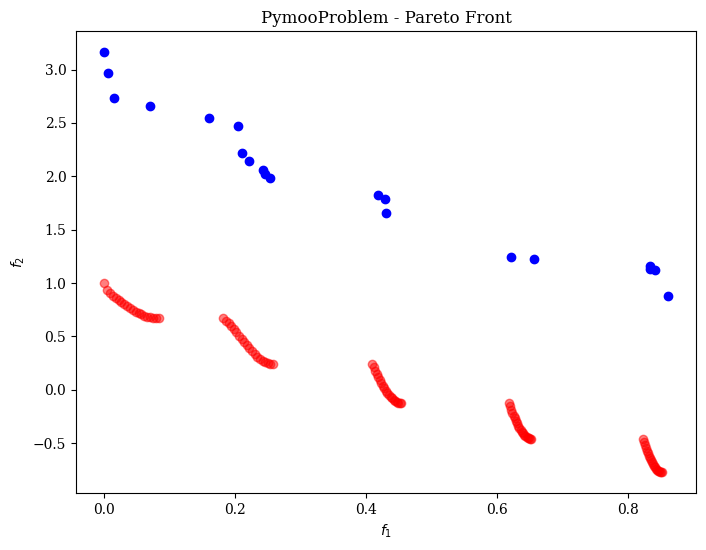

In [7]:
front = problem.plot_pareto_front(True)
front.show()

## Second try, optimizing hyperparameters

In [8]:
def print_result(result):
    print("\n" + "=" * 40)
    print("RESULTS")
    print("=" * 40)
    print(f"Problem: {result.problem_name}")
    print(f"Evaluations used: {result.evaluations_used}")
    print(f"Generations: {len(result.history)}")
    print(f"Metrics:")
    for metric, value in result.metrics.items():
        print(f"  - {metric}: {value}")
    

Gen 0: Evals=50/10000, Pareto size=6, Sample objectives=['0.6394', '2.3997']
Gen 10: Evals=550/10000, Pareto size=13, Sample objectives=['0.1831', '3.0208']
Gen 20: Evals=1050/10000, Pareto size=15, Sample objectives=['1.0000', '0.4946']
Gen 30: Evals=1550/10000, Pareto size=23, Sample objectives=['0.2376', '1.1183']
Gen 40: Evals=2050/10000, Pareto size=40, Sample objectives=['0.2038', '0.7396']
Gen 50: Evals=2550/10000, Pareto size=55, Sample objectives=['1.0000', '0.0653']
Gen 60: Evals=3050/10000, Pareto size=57, Sample objectives=['0.0000', '1.1125']
Gen 70: Evals=3550/10000, Pareto size=87, Sample objectives=['0.0121', '0.9330']
Gen 80: Evals=4050/10000, Pareto size=120, Sample objectives=['0.0000', '1.0268']
Gen 90: Evals=4550/10000, Pareto size=140, Sample objectives=['0.1356', '0.8062']
Gen 100: Evals=5050/10000, Pareto size=148, Sample objectives=['0.0337', '0.9253']
Gen 110: Evals=5550/10000, Pareto size=158, Sample objectives=['0.1159', '0.7299']
Gen 120: Evals=6050/10000, 

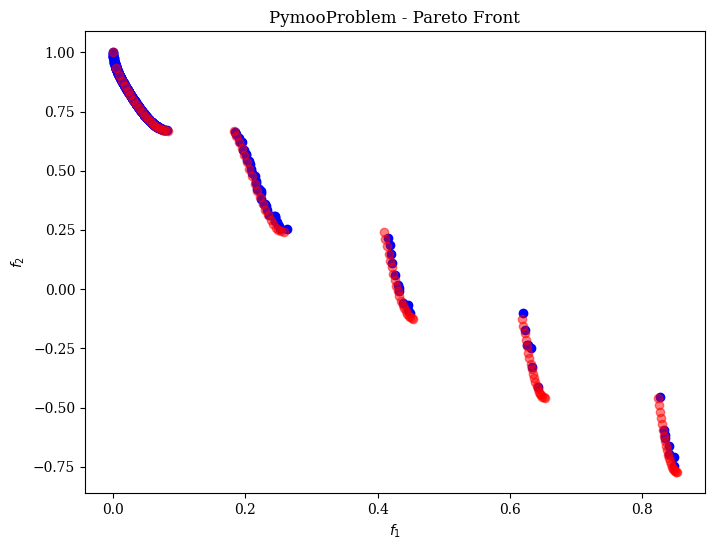

In [9]:
config = ProblemConfig(max_evaluations=10000, seed=42, output_dir="results/zdt1")

# Problem
name = "zdt3"
problem = PymooProblem(config, name, n_var=30)

# Operators
initialization = RandomInitialization()
selection = ParetoSelection()
crossover = BlendCrossover(alpha=1)
mutation = UniformMutation(mutation_rate=0, bounds=problem.get_bounds())
replacement = GenerationalReplacement()

# Genetic Algorithm
ga = GeneticAlgorithmMO(
    problem=problem,
    population_size=50,
    initialization=initialization,
    selection=selection,
    crossover=crossover,
    mutation=mutation,
    replacement=replacement,
)

result = ga.run()

print_result(result)

front = problem.plot_pareto_front(True)
front.show()

# NSGA-II

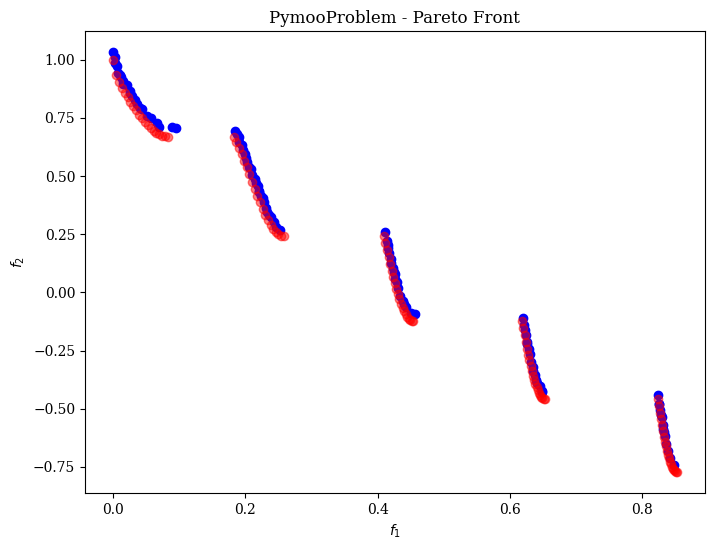

In [10]:
res2 = problem.get_nsga2_result()
front2 = problem.plot_pareto_front(True)
front2.show()